# **Sources PSFs Analysis | Baseline VS MaskShift with Decoder Correction**

In [1]:
from pathlib import Path
from typing import Any

import numpy as np
from numpy.typing import NDArray

from bloodmoon.types import CoordEquatorial
from bloodmoon.mask import CodedMaskCamera, codedmask
import darksun as ds

from IROSrec.handle import config_dirpaths
import imgmaker as mgm

ds.show.set_figures_darkbkg()

In [2]:
MASK_FITS: str = "mask_NTHT_20260129_CORRECTED.fits"
UPS_X, UPS_Y = 2, 1

SKYFIELD: str = "CameraGeometry"

DATA_FITS_bline: str = "baseline_2-50keV_1ks"
RUN_ID_bline: str = 'baseline_wcxb'

DATA_FITS_mshift: str = "mask_Z2arcmin_2-50keV_1ks"
RUN_ID_mshift: str = 'mask_Z2arcmin_wcxb'

ID_CAMERA_A: str = "cam1a"
DATASET: str = "detected"

VIGNETTING: bool = True
PSFY: bool = mgm.config_psfy_flag(DATASET)

E_min, E_max = 2.0, 50.0           # [keV]
# exclude_coords: CoordEquatorial | list[CoordEquatorial] | None = [
#         CoordEquatorial(318.950871147977, -51.1920260999562),   # s0
#         CoordEquatorial(296.376333558386, 5.25424886863538),    # s1
#         CoordEquatorial(236.423666441614, 5.25424886863538),    # s2
#         CoordEquatorial(213.849128852023, -51.1920260999562),   # s3
#         CoordEquatorial(286.170341181402, -42.2037736309785),   # s4
#         CoordEquatorial(281.331753525598, -13.4867719837475),   # s5
#         CoordEquatorial(251.468246474402, -13.4867719837475),   # s6
#         CoordEquatorial(246.629658818598, -42.2037736309785),   # s7
#         CoordEquatorial(266.4, -28.94),                         # s8
#     ]
exclude_coords: CoordEquatorial | list[CoordEquatorial] | None = None

In [3]:
MASK_PATH, SIMUL_DATA_PATH_bline, SAVE_PATH_bline = config_dirpaths(
    mask=MASK_FITS,
    skyfield=SKYFIELD,
    simul=DATA_FITS_bline,
    runID=RUN_ID_bline,
)
_, SIMUL_DATA_PATH_mshift, SAVE_PATH_mshift = config_dirpaths(
    mask=MASK_FITS,
    skyfield=SKYFIELD,
    simul=DATA_FITS_mshift,
    runID=RUN_ID_mshift,
)
# OUT_RESULTS_PATH = '/home/edoardo/Desktop'
OUT_RESULTS_PATH = '/mnt/d/PhD_AASS/Coding/Images_fits'

sdlA_bline = ds.get_data(
    SIMUL_DATA_PATH_bline + f'{ID_CAMERA_A}/{DATA_FITS_bline}_{ID_CAMERA_A}_{DATASET}.fits',
    E_min=E_min, E_max=E_max, coords=exclude_coords,
)
sdlA_mshift = ds.get_data(
    SIMUL_DATA_PATH_mshift + f'{ID_CAMERA_A}/{DATA_FITS_mshift}_{ID_CAMERA_A}_{DATASET}.fits',
    E_min=E_min, E_max=E_max, coords=exclude_coords,
)

logA_bline, _ = ds.load_database(f"{SAVE_PATH_bline}/OUT_{RUN_ID_bline}_srcDB.fits")
logA_mshift, _ = ds.load_database(f"{SAVE_PATH_mshift}/OUT_{RUN_ID_mshift}_srcDB.fits")
cu_map = mgm.get_srcmap_for_unit(logA_bline.log['ID'], logA_mshift.log['ID'])

# Loading data...
# Loading completed!
# Loading data...
# Loading completed!


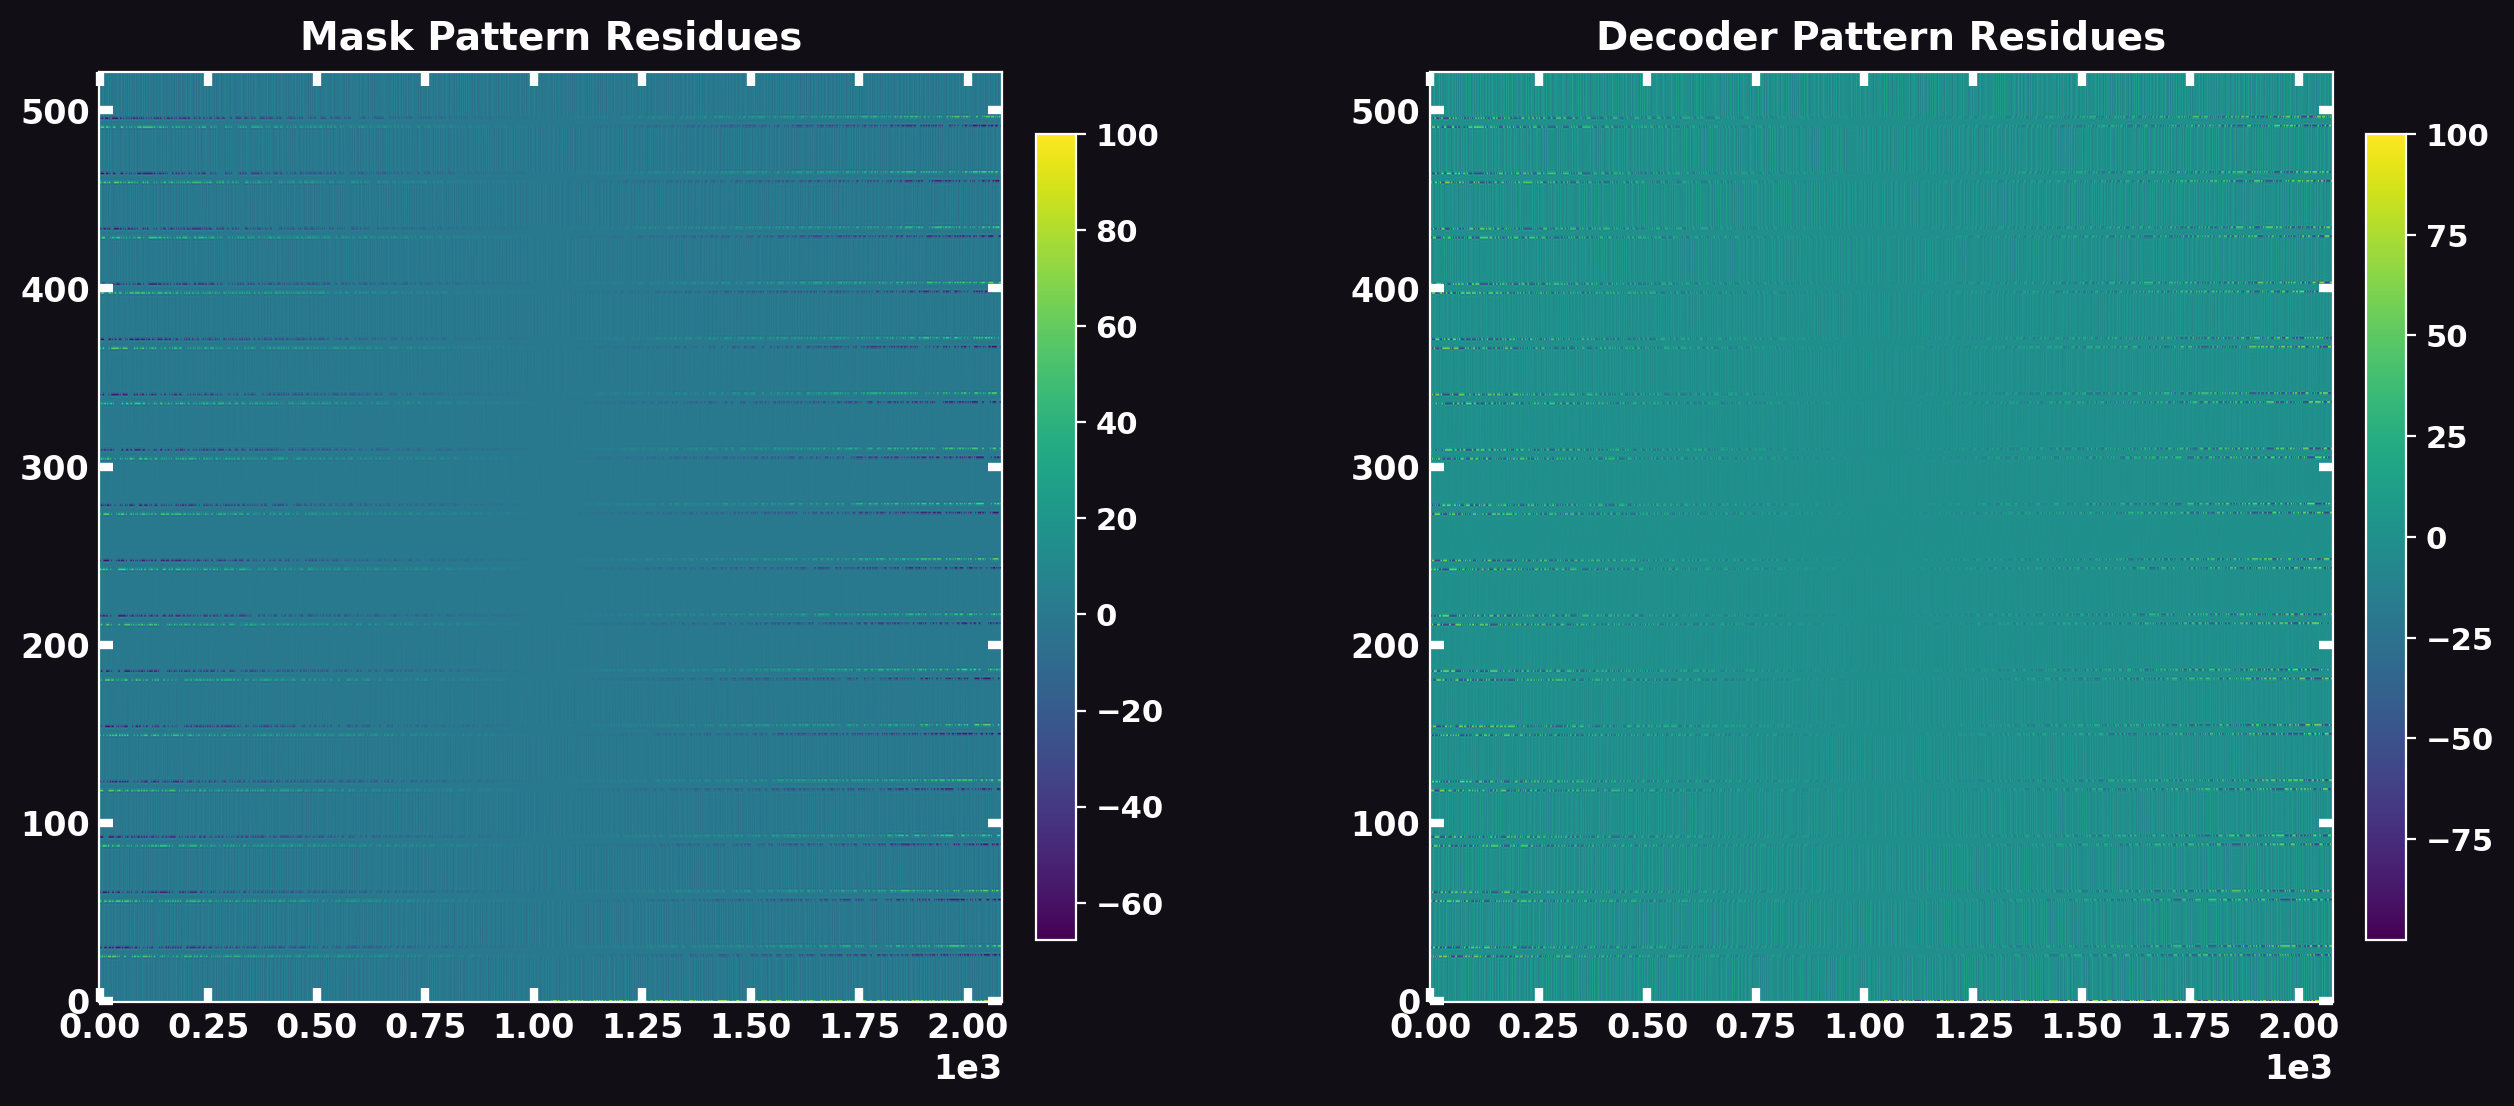

In [4]:
from bloodmoon.mask import count, decode

wfm: CodedMaskCamera = codedmask(MASK_PATH, UPS_X, UPS_Y, mask_pattern_shift=2.0)
wfm_noshift: CodedMaskCamera = codedmask(MASK_PATH, UPS_X, UPS_Y)

ASPECT = wfm.shape_detector[1] / wfm.shape_detector[0]
ds.image_plot(
    dmaps=(
        ds.map4image(img=(wfm_noshift.mask - wfm.mask) * 100, title='Mask Pattern Residues', img_kwargs=dict(aspect=ASPECT)),
        ds.map4image(img=(wfm_noshift.decoder - wfm.decoder) * 100, title='Decoder Pattern Residues', img_kwargs=dict(aspect=ASPECT)),
    ),
    ncols=2,
)

In [5]:
d_bline: NDArray = count(wfm_noshift, sdlA_bline.DLdata)[0]
skymap_bline: NDArray = decode(wfm_noshift, d_bline)

d_mshift: NDArray = count(wfm, sdlA_mshift.DLdata)[0]
skymap_mshift: NDArray = decode(wfm, d_mshift)

In [6]:
def custom_slices_plot(
    camera: CodedMaskCamera,
    sky: NDArray | tuple[NDArray],
    pos: tuple[int, int],
    crp: tuple[int, int],
    *,
    title_prefix: str | None = None,
    ylabel: str | None = None,
    ylim_xslice: tuple[Any, Any] | None = None,
    ylim_yslice: tuple[Any, Any] | None = None,
    labels: str | tuple[str | None] | None = None,
    color: str | tuple[str] | None = None,
    save_to: str | Path | None = None,
    **kwargs: Any,
) -> None:
    """
    Plots horizontal and vertical slices of 2D data arrays centered at a given position.
    """
    def phase(x: NDArray) -> NDArray:
        """Centers x-axis values around zero."""
        return np.arange(len(x) + 1) - len(x) // 2 - 0.5
    
    cropped = tuple(
        ds.crop(s, pos, crp, strict=False) for s in (
            (sky,) if isinstance(sky, np.ndarray) else sky
        )
    )
    xslice, yslice = zip(
        *tuple((c[crp[0], :], c[:, crp[1]]) for c in cropped)
    )
    title_prefix_ = f'{title_prefix} | ' if title_prefix is not None else ''
    dtx, dty = ds.pixels_angular_resolution(camera, verbose=False)
    kws = {
        'ylabel': ylabel or 'counts [ph]',
        'labels': labels,
        'style': 'stairs',
        'color': color,
    }
    dmapx = ds.map4plot(
        arrs=xslice,
        title=f"{title_prefix_}" + "PSF Fine Direction",
        xlabel='$\\theta_{fine}$ [arcmin]',
        x=map(lambda x: dtx * phase(x), xslice),
        ylim=ylim_xslice or (None, None),
        **kws,
    )
    dmapy = ds.map4plot(
        arrs=yslice,
        title=f"{title_prefix_}" + "PSF Coarse Direction",
        xlabel='$\\theta_{coarse}$ [deg]',
        x=map(lambda y: dty * phase(y) / 60, yslice),
        ylim=ylim_yslice or (None, None),
        **kws,
    )
    ds.plot(
        dmaps=(dmapx, dmapy),
        ncols=2,
        save_to=save_to,
        **kwargs,
    )
    return

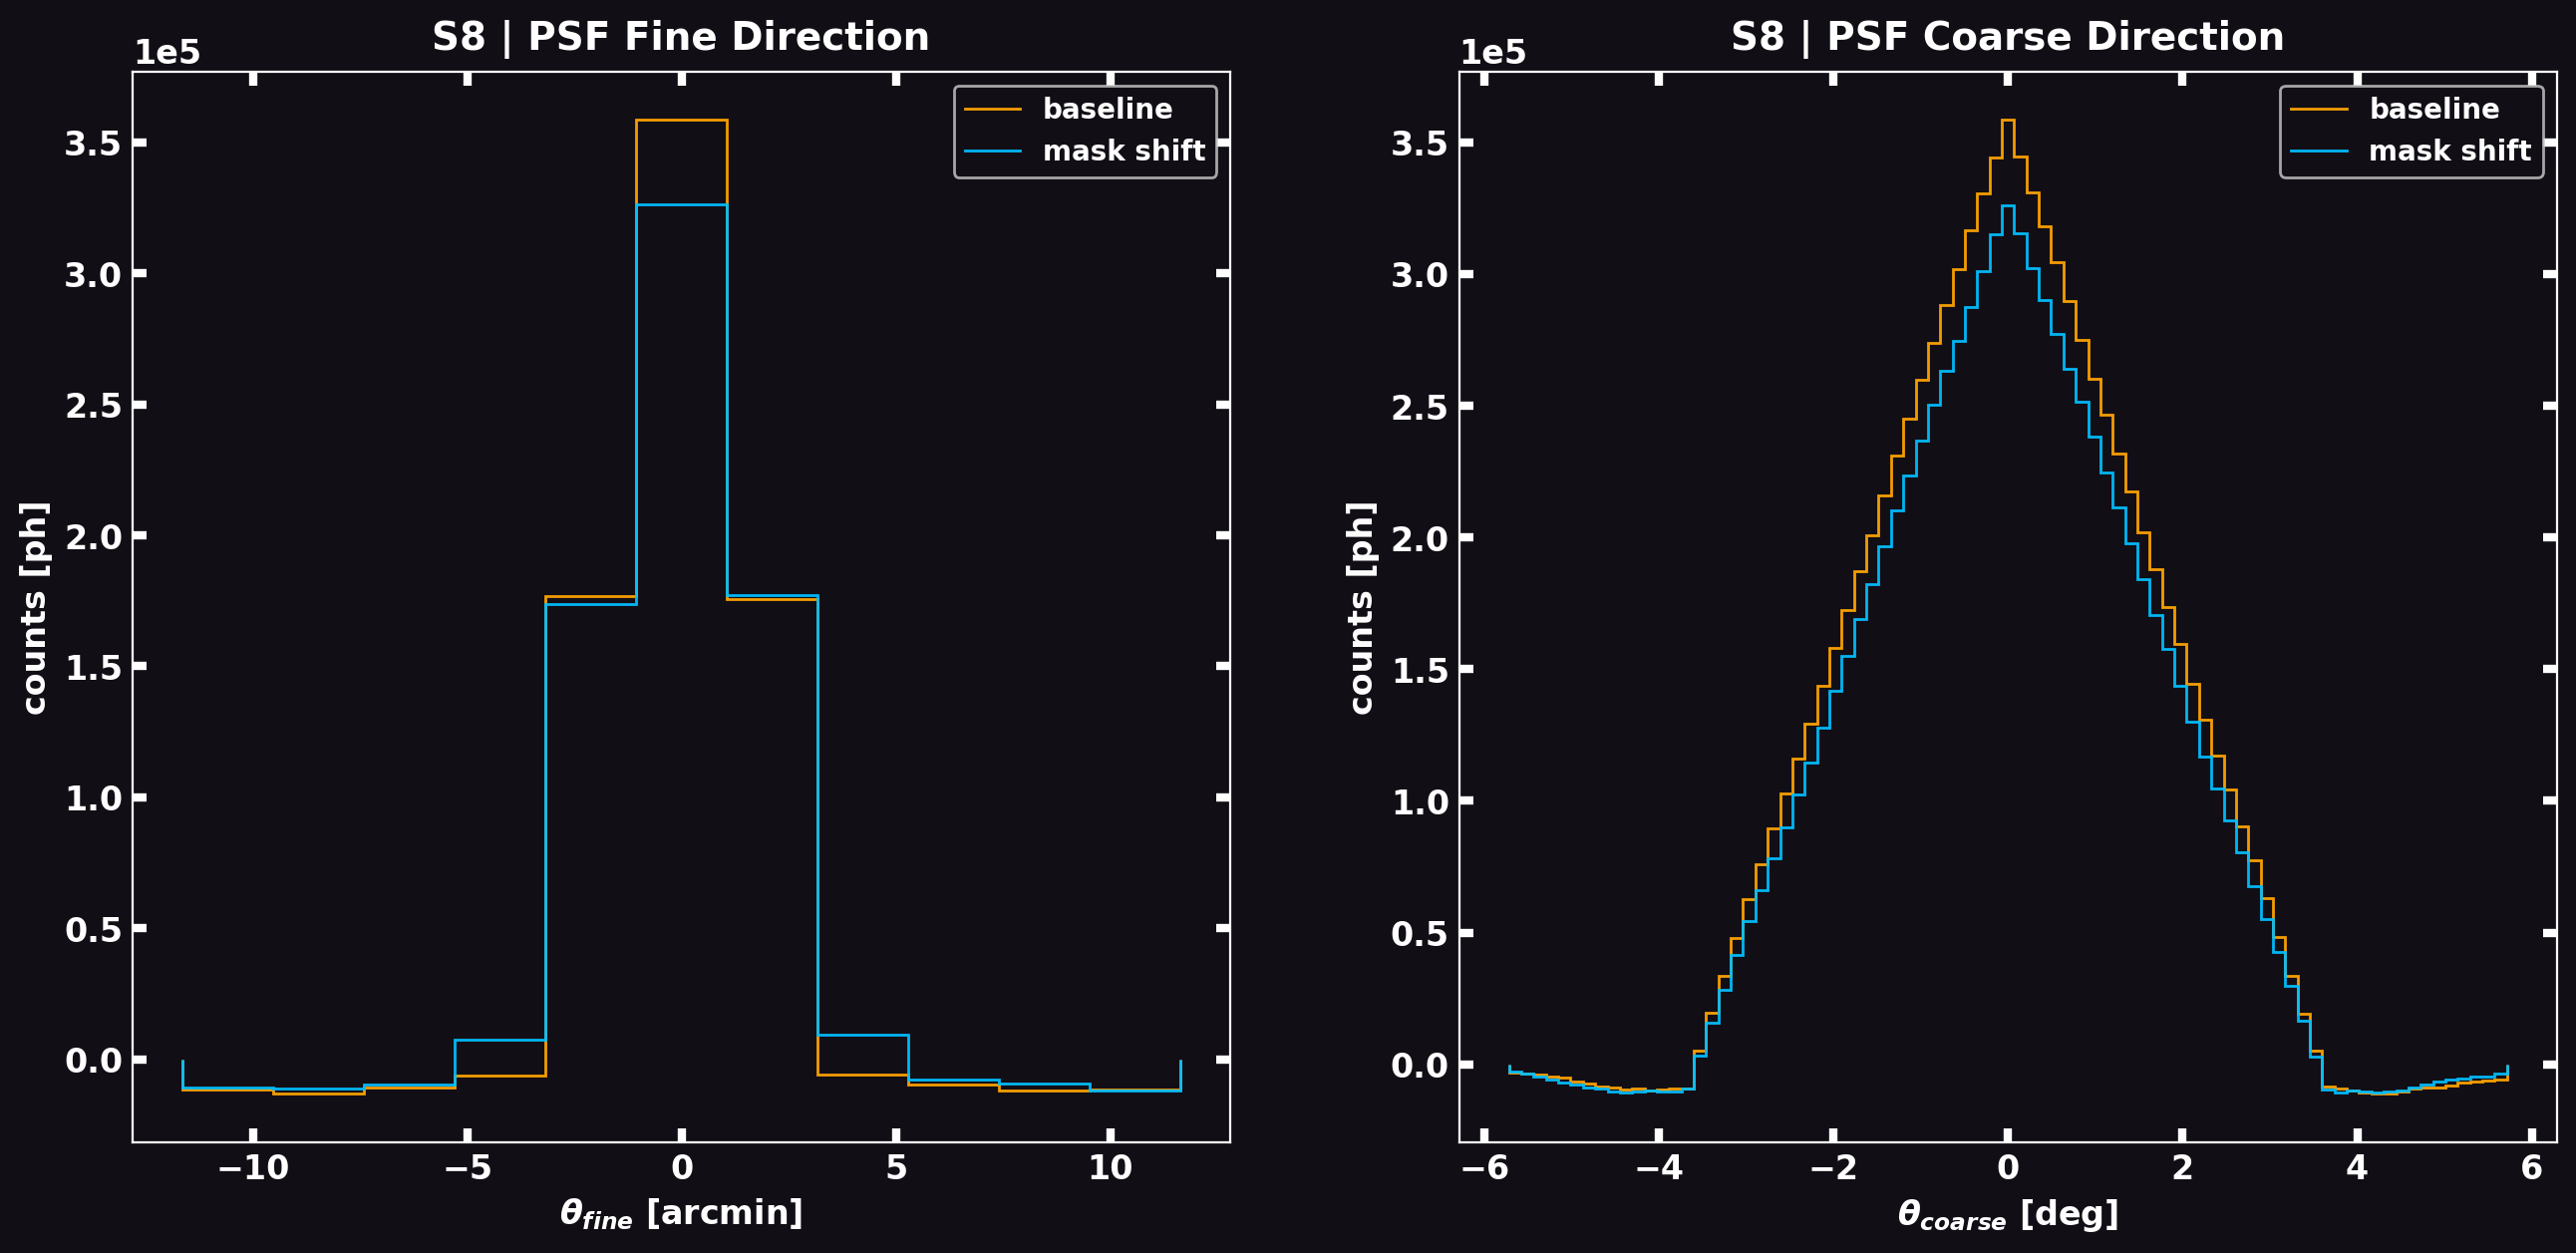

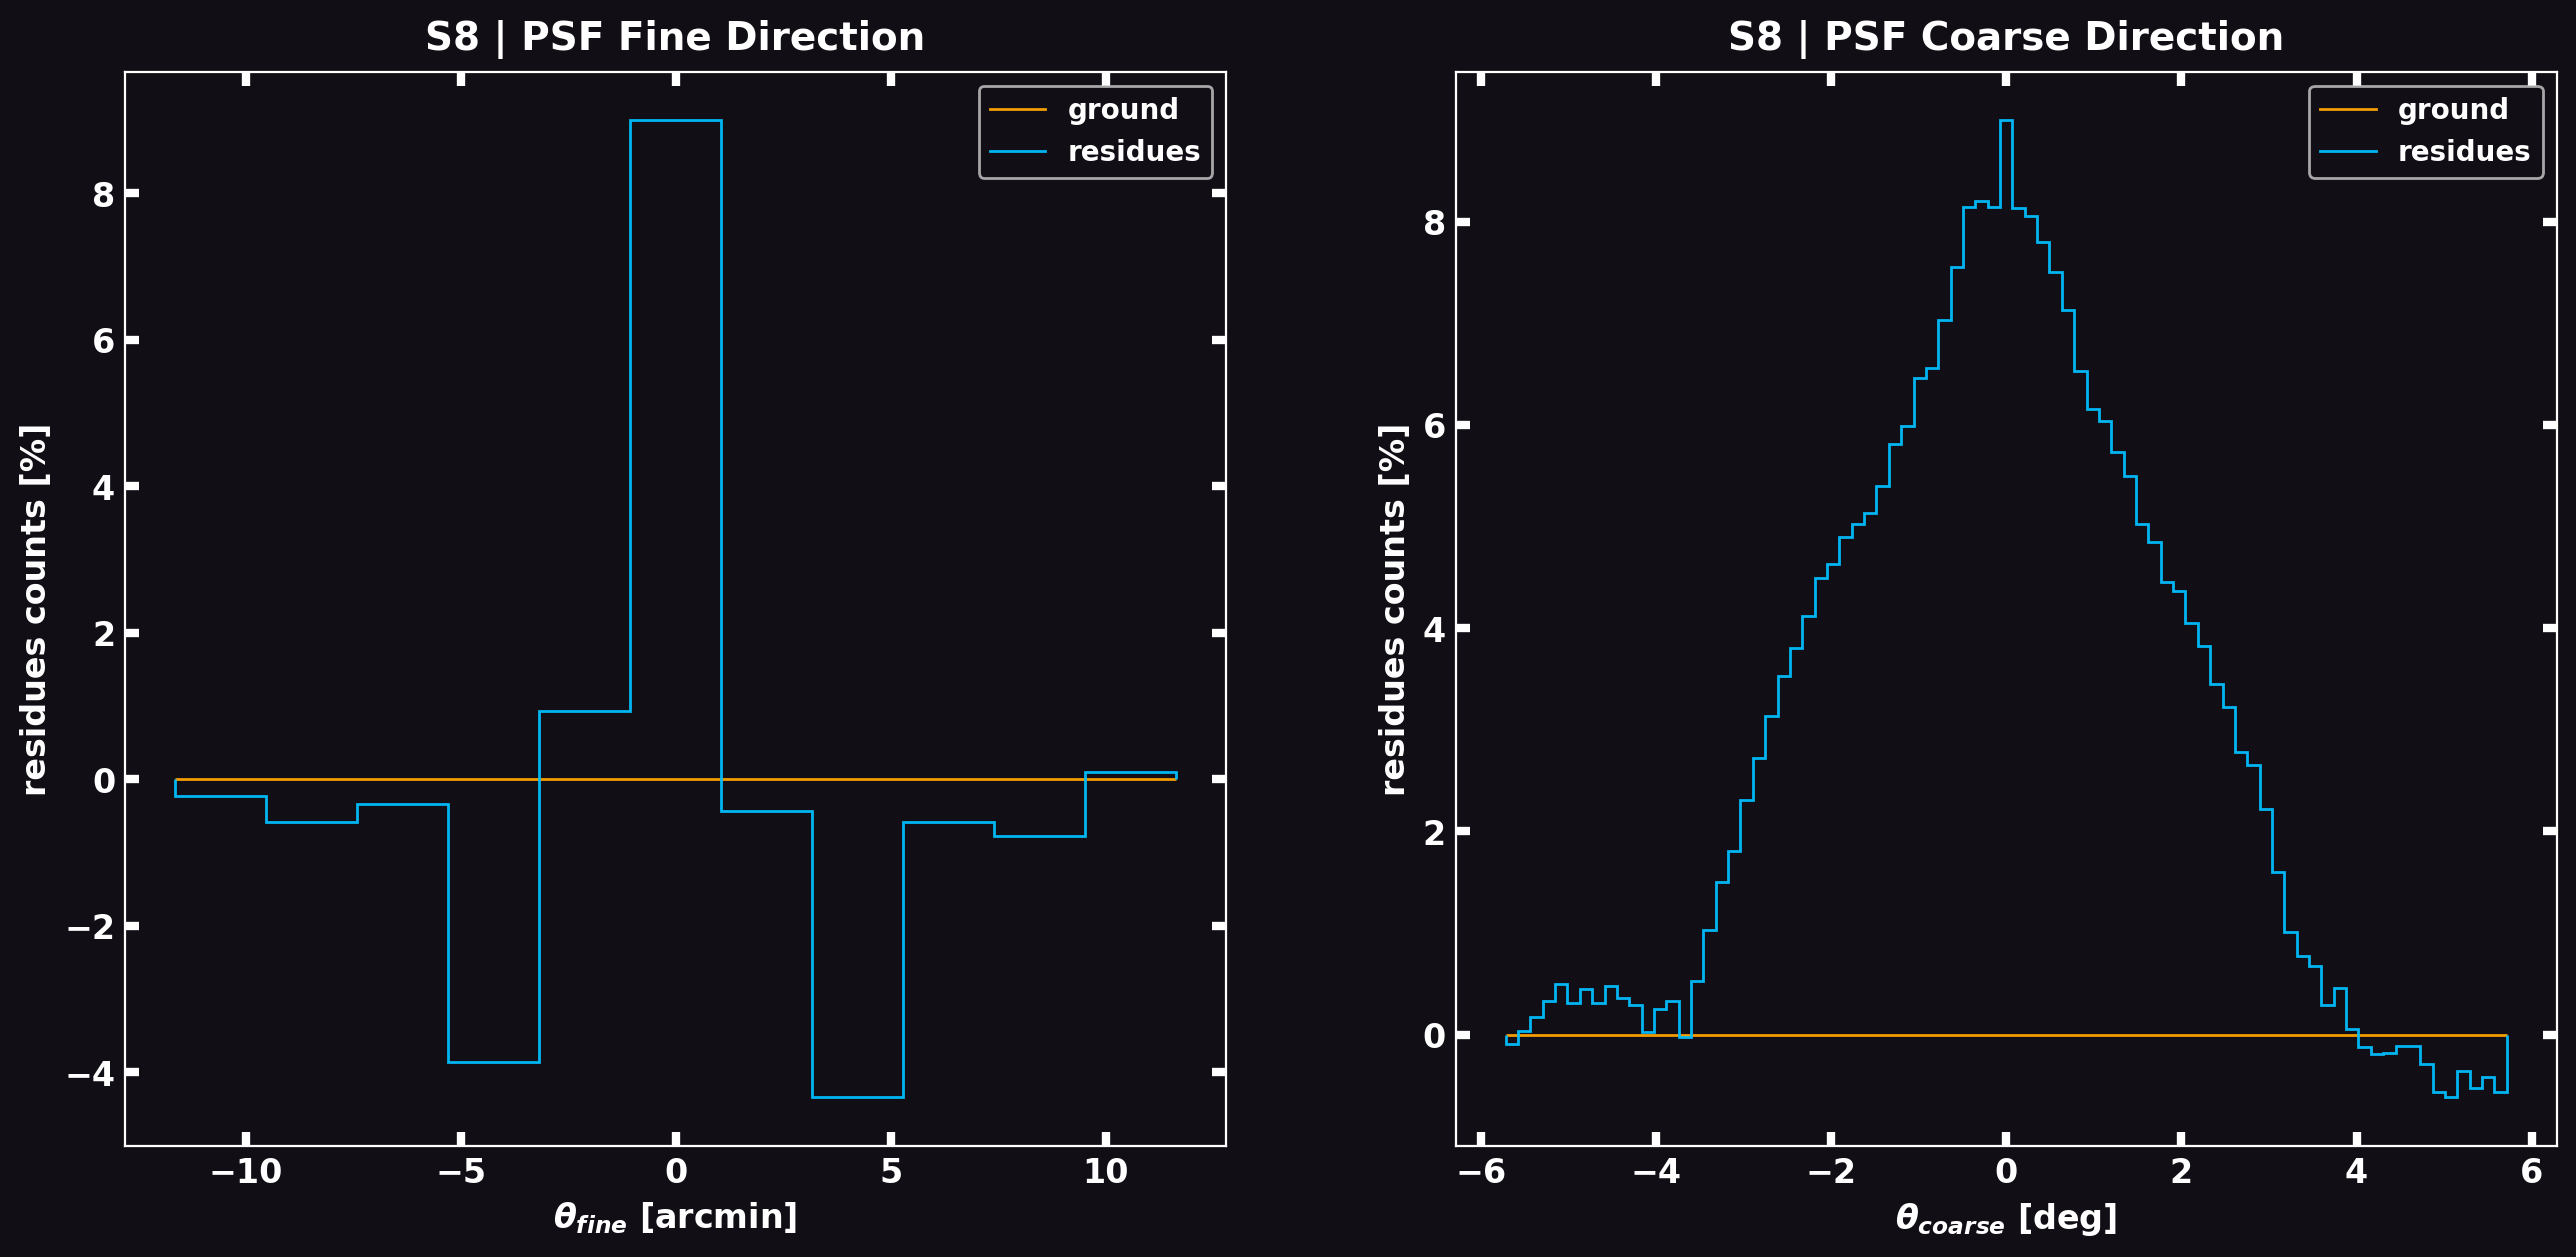

In [7]:
SRC_ID: str = 's8'


IDX: int = int(np.argwhere(cu_map.common == SRC_ID)[0, 0])
KWS = {
    'pos': (np.array(logA_bline.log['y'])[cu_map.idx_a][IDX], np.array(logA_bline.log['x'])[cu_map.idx_a][IDX]),
    'crp': (40 * UPS_Y, 2 * UPS_X + 1),
    'title_prefix': SRC_ID.upper(),
    'color': ('Orange', 'DeepSkyBlue'),
}
residues = (skymap_bline - skymap_mshift) * 100 / skymap_bline[KWS['pos']]
# ratio = np.clip(skymap_mshift, a_min=1, a_max=None) / np.clip(skymap_bline, a_min=1, a_max=None)

custom_slices_plot(
    camera=wfm,
    sky=(skymap_bline, skymap_mshift),
    labels=('baseline', 'mask shift'),
    # save_to=f'{OUT_RESULTS_PATH}/psf_slices_{E_min}-{E_max}keV.pdf',
    **KWS,
)
custom_slices_plot(
    camera=wfm,
    sky=(np.zeros_like(residues), residues),
    labels=('ground', 'residues'),
    ylabel=r'residues counts [%]',
    # save_to=f'{OUT_RESULTS_PATH}/psf_slices_res_{E_min}-{E_max}keV.pdf',
    **KWS,
)
# custom_slices_plot(
#     camera=wfm,
#     sky=(np.ones_like(ratio), ratio),
#     labels=('ground', 'ratio'),
#     ylabel=r'ratio',
#     # save_to=f'{OUT_RESULTS_PATH}/psf_slices_ratio_{E_min}-{E_max}keV.pdf',
#     **KWS,
# )

In [8]:
import matplotlib.pyplot as plt
from darksun.show import DSPlot, export_pltparams

def custom_PSF_hmap(
    camera: CodedMaskCamera,
    psf: NDArray,
    residues: NDArray,
    xticks: NDArray,
    yticks: NDArray,
    title_prefix: str | None = None,
    save_to: str | Path | None = None,
) -> None:
    """
    Plots the true PSF of given source and residues wrt `bm` template from IROS.
    """    
    PLOTPARAMS = export_pltparams()
    n, m = psf.shape
    dtx, dty = ds.pixels_angular_resolution(camera, verbose=False)
    _yticks_lbl, _xticks_lbl = dty / 60 * (yticks - n // 2), dtx * (xticks - m // 2)
    yticks_lbl, xticks_lbl = map(lambda arr: [float(f'{a:.1f}') for a in arr], (_yticks_lbl, _xticks_lbl))
    aspect = 2 * KWS['crp'][1] / KWS['crp'][0]
    title_prefix_ = f'{title_prefix} | ' if title_prefix is not None else ''

    # res_ = residues * 100 / psf[(n - 1) // 2, (m - 1) // 2]
    valres = max(abs(residues.min()), abs(residues.max()))

    dsp = DSPlot(2, 1)
    fig, axs = dsp.config_subplots(size=6, ptype='image')
    fig.subplots_adjust(wspace=-1e-1)

    # - IMG axis 0  |  PSF
    dsp.config_labels(axs[0], f'{title_prefix_}PSF', '$\\theta_{fine}$ [arcmin]', '$\\theta_{coarse}$ [deg]')
    img = axs[0].imshow(psf, origin=PLOTPARAMS['cbar_origin'], cmap='gist_heat', aspect=aspect)
    cbar = fig.colorbar(
        img, ax=axs[0], location='right', shrink=PLOTPARAMS['cbar_shrink'],
        pad=PLOTPARAMS[f'cbar_pad_right'],
    )
    cbar.ax.tick_params(labelsize=PLOTPARAMS['cbar_ticks_ls'])
    cbar.set_label(
        'counts [ph]', fontsize=PLOTPARAMS['cbar_label_fs'], fontweight=PLOTPARAMS['cbar_label_fw'],
    )

    # - IMG axis 1  |  Residues (true-template)
    dsp.config_labels(axs[1], f'{title_prefix_}Residues', '$\\theta_{fine}$ [arcmin]', '$\\theta_{coarse}$ [deg]')
    img = axs[1].imshow(
        residues, origin=PLOTPARAMS['cbar_origin'], cmap='viridis', aspect=aspect, vmin=-valres, vmax=valres,
    )
    cbar = fig.colorbar(
        img, ax=axs[1], location='right', shrink=PLOTPARAMS['cbar_shrink'],
        pad=PLOTPARAMS[f'cbar_pad_right'],
    )
    cbar.ax.tick_params(labelsize=PLOTPARAMS['cbar_ticks_ls'])
    cbar.set_label(
        'residues counts [%]', fontsize=PLOTPARAMS['cbar_label_fs'], fontweight=PLOTPARAMS['cbar_label_fw'],
    )
    
    for ax in axs:
        ax.xaxis.set_ticks_position('both')
        ax.yaxis.set_ticks_position('both')
        ax.tick_params(
            which='both', direction='in', width=3, length=5 if 'major' else 2,
        )
        ax.set_yticks(yticks, yticks_lbl)
        ax.set_xticks(xticks, xticks_lbl)

    if save_to is not None: fig.savefig(save_to)
    plt.show()

    return

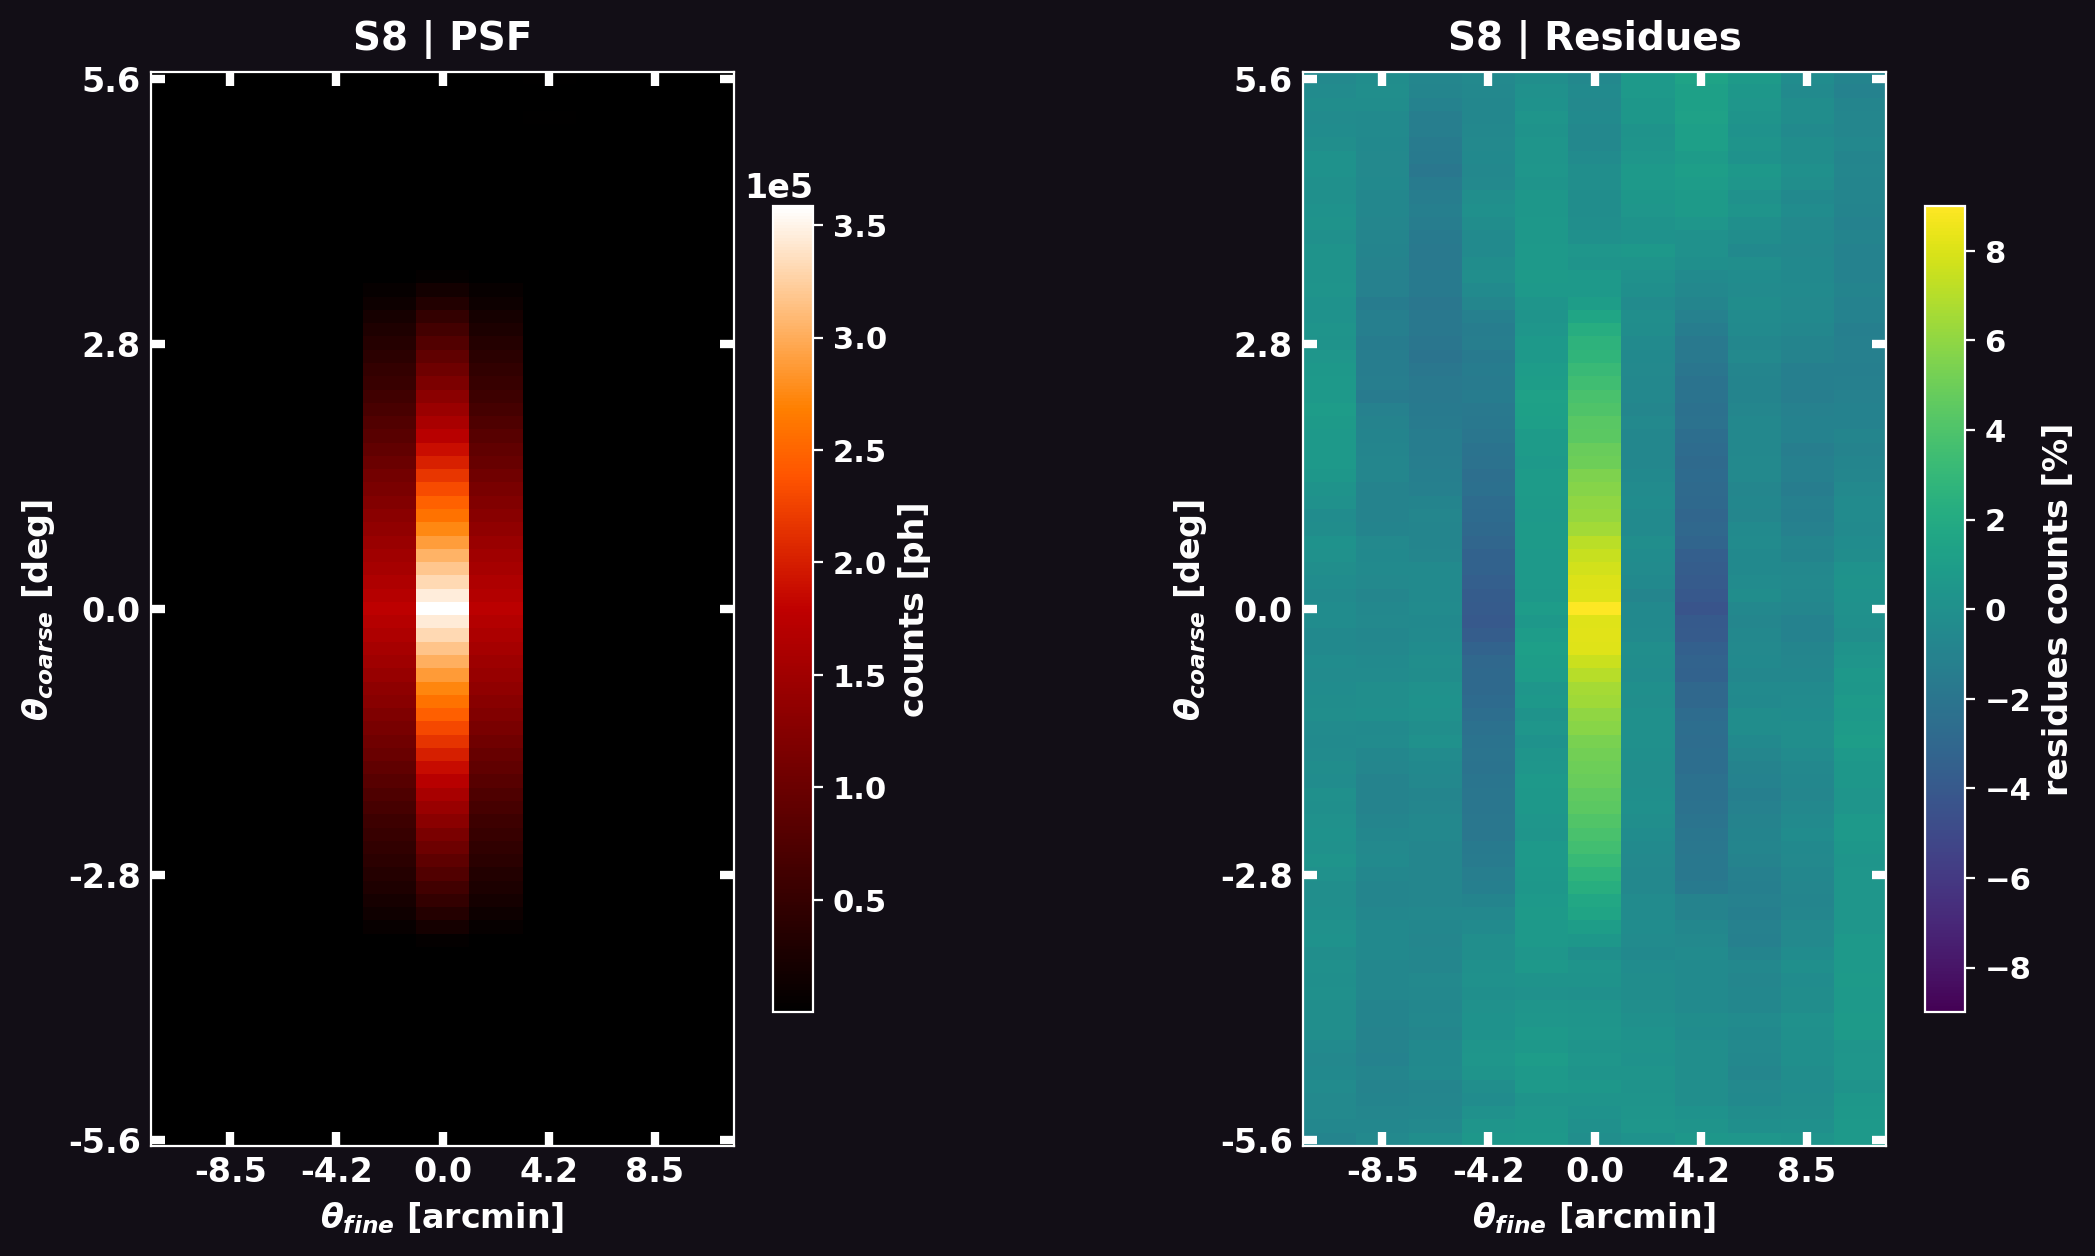

In [9]:
src_psf, src_res = map(lambda x: ds.crop(x, KWS['pos'], KWS['crp']), (skymap_bline, residues))

n, m = src_psf.shape
yticks, xticks = np.arange(n)[::20], (np.arange(m)[::UPS_X] + 1)[:-1]

custom_PSF_hmap(
    camera=wfm,
    psf=np.clip(src_psf, a_min=1, a_max=src_psf.max()),
    residues=src_res,
    xticks=xticks,
    yticks=yticks,
    title_prefix=KWS['title_prefix'],
    # save_to=f'{OUT_RESULTS_PATH}/psfHM_{E_min}-{E_max}keV.pdf'
)

<br>

<br>

<br>

## **Rotation Tests**

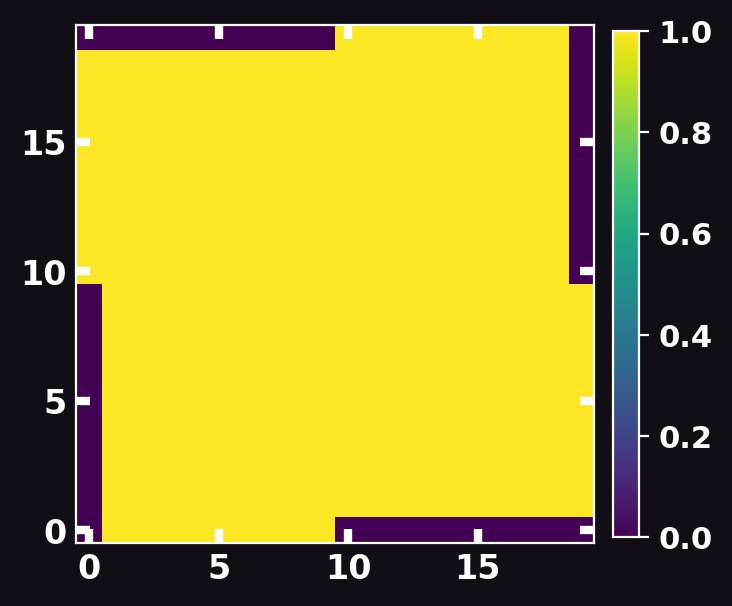

In [10]:
import scipy.ndimage as nd

def custom_rotate(pattern: NDArray, angle: float) -> NDArray:
    """Rotates the given pattern."""
    # `mask_pattern_shift` is multiplied by -1 to match angle anti-clockwise
    # rotation, and is divided by 60 to convert it from [arcmin] to [deg]
    ROTKWS = {
        'angle': (-1) * angle,
        'order': 4,
        'reshape': False,
        'mode': 'constant',
        'cval': 0.0,
    }
    return nd.rotate(pattern, **ROTKWS)


size = 20
pattern = np.ones((size, size), dtype=np.float32)
# pattern[5 : -5, 5 : -5] = 2
rot = custom_rotate(pattern, 5)

ds.image_plot(ds.map4image(img=rot), size=4)

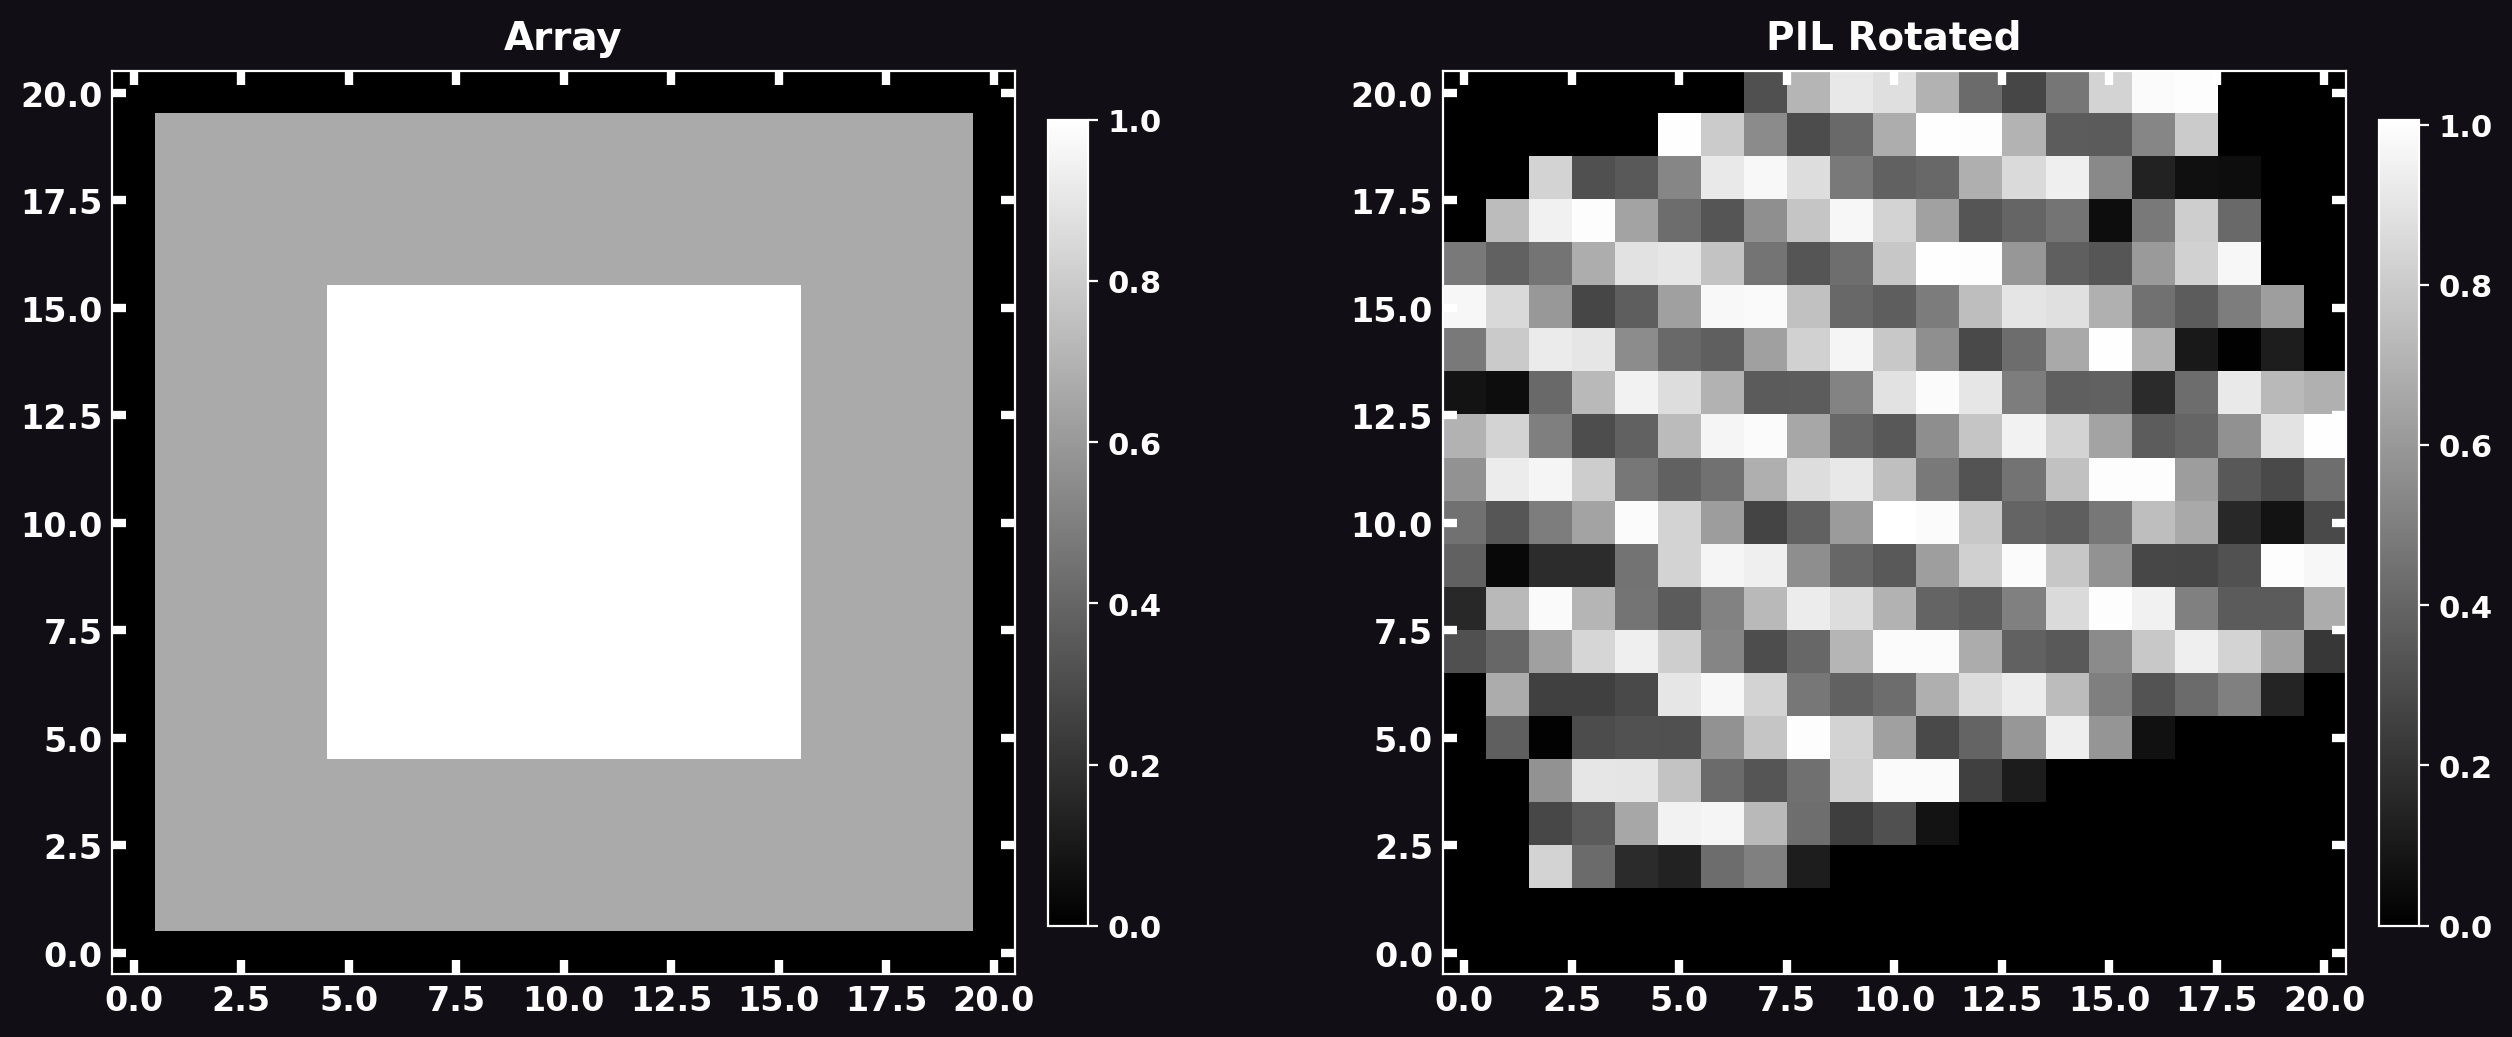

In [27]:
from PIL import Image


class ImgMapping:
    def __init__(self, arr: NDArray) -> None:
        self.arr = arr
        self.xi = arr.max()
        self.eta = arr.min()
    
    def normalise(self) -> NDArray:
        """Normalises array in [0, 1]."""
        arr_ = (self.arr - self.eta) / (self.xi - self.eta)
        return arr_
    
    def remap(self, target: NDArray) -> NDArray:
        """Remaps given target wrt `arr` values."""
        return self.eta + (self.xi - self.eta) * target



size = 21
pattern = np.zeros((size, size), dtype=np.float32)
pattern[1 : -1, 1 : -1] += 1.0
pattern[5 : -5, 5 : -5] += 0.5
normap = ImgMapping(pattern)

normed = normap.normalise()
a = Image.fromarray(normed, 'L')
# a = Image.frombytes('L', normed.shape, normed)
img_rot = a.rotate(
    angle=-20,
    resample=Image.Resampling.BILINEAR,
    fillcolor=0,
)
rot = normap.remap(np.array(img_rot).astype(np.float32) / 255)


ds.image_plot(
    dmaps=(
        ds.map4image(img=normed, title='Array', img_kwargs=dict(cmap='grey')),
        ds.map4image(img=rot, title='PIL Rotated', img_kwargs=dict(cmap='grey')),
    ),
    ncols=2,
)

In [ ]:
# NOTE: CodedMaskCamera with mask shift correction


# class CodedMaskCamera:
#     """
#     Dataclass containing a coded mask camera system.

#     Handles mask pattern, detector geometry, and related calculations for coded mask imaging.
#     Uses callable thunks for lazy loading of mask data to maintain hashability and performance.

#     Args:
#         get_mask: Callable that returns mask pattern as 2D array
#         get_decoder: Callable that returns decoder pattern as 2D array
#         get_bulk: Callable that returns bulk pattern as 2D array
#         specs: CodedMaskSpecs containing geometric parameters and dimensions
#         upscale_f: Tuple of upscaling factors for x and y dimensions
#         hide_bulk_els_x: Detector physical elements to hide along fine axis, default=`0.0` [mm].
#         hide_bulk_els_y: Detector physical elements to hide along coarse axis, default=`0.0` [mm].
#         mask_pattern_shift: Shift angle between mask pattern and detector, default=`0.0` [arcmin].

#     Raises:
#         ValueError: If detector plane is larger than mask or if upscale factors are not positive
#     """

#     # note that we are taking thunks here, rather than the actual array.
#     # two reasons for this:
#     #   1. python functions are hashable and using thunks keeps camera objects hashable themselves.
#     #   2. reading data may take time. thunk delays this expensive operation.
#     get_mask: Callable[[], NDArray]
#     get_decoder: Callable[[], NDArray]
#     get_bulk: Callable[[], NDArray]
#     specs: CodedMaskSpecs
#     upscale_x: int = 1
#     upscale_y: int = 1
#     hide_bulk_els_x: int | float = 0.0
#     hide_bulk_els_y: int | float = 0.0
#     mask_pattern_shift: int | float = 0.0

#     @cached_property
#     def upscale_f(self):
#         return UpscaleFactor(x=self.upscale_x, y=self.upscale_y)

#     @cached_property
#     def shape_detector(self) -> tuple[int, int]:
#         """Shape of the detector array (rows, columns)."""
#         return len(self.bins_detector.y) - 1, len(self.bins_detector.x) - 1

#     @cached_property
#     def shape_mask(self) -> tuple[int, int]:
#         """Shape of the mask array (rows, columns)."""
#         # there is no need for this since we can just `mask.shape` but since we have the other already..
#         return len(self.bins_mask.y) - 1, len(self.bins_mask.x) - 1

#     @cached_property
#     def shape_sky(self) -> tuple[int, int]:
#         """Shape of the reconstructed sky image (rows, columns)."""
#         n, m = self.shape_detector
#         o, p = self.shape_mask
#         return n + o - 1, m + p - 1
    
#     def _mask_detector_artefacts(self, bulk: NDArray) -> NDArray:
#         """
#         Builds a mask for the detector plane edges, accounting for possible
#         artefacts emerging from the reconstruction algorithm used to fit a
#         detected photon position.\\
#         Input `hide_bulk_els_x` and `hide_bulk_els_y` are expressed in [mm] and
#         represent the physical size of the mask on top of the detector plane
#         surface along the fine and coarse directions, starting from the boundaries.
#         """
#         if not any((self.hide_bulk_els_x, self.hide_bulk_els_y)):
#             return np.ones_like(bulk)
#         print(f'UserInfo: using bulk mask of [{self.hide_bulk_els_x} x {self.hide_bulk_els_y}] mm.')
#         active_elements = np.array((bulk > 0), dtype=int)
#         npx_to_hide_x = int(self.hide_bulk_els_x * self.upscale_f.x / self.specs.mask_deltax)
#         edges_cover_x = (
#             (_shift(active_elements, 0, -npx_to_hide_x) > 0) & (_shift(active_elements, 0, npx_to_hide_x) > 0)
#         )
#         npx_to_hide_y = int(self.hide_bulk_els_y * self.upscale_f.y / self.specs.mask_deltay)
#         edges_cover_y = (
#             (_shift(active_elements, -npx_to_hide_y, 0) > 0) & (_shift(active_elements, npx_to_hide_y , 0) > 0)
#         )
#         return active_elements * edges_cover_x * edges_cover_y
    
#     def _rotate(self, pattern: NDArray) -> NDArray:
#         """
#         Rotates the given pattern with respect to the detector plane,
#         around the camera optical axis. The pattern is rotated by the
#         input `mask_pattern_shift` angle, expressed in [arcmin].
#         """
#         # `mask_pattern_shift` is multiplied by -1 to match angle anti-clockwise
#         # rotation, and is divided by 60 to convert it from [arcmin] to [deg]
#         ROTKWS = {
#             'angle': (-1) * self.mask_pattern_shift / 60.0,
#             'axes': (1, 0),
#             'reshape': False,
#             'order': 4,
#             'mode': 'constant',
#             'cval': 0.0,
#         }
#         return rotate(pattern, **ROTKWS)

#     def _bins_mask(
#         self,
#         upscale_f: UpscaleFactor,
#     ) -> BinsRectangular:
#         """Returns bins for mask with given upscale factors."""
#         l, r = self.specs.mask_minx, self.specs.mask_maxx
#         b, t = self.specs.mask_miny, self.specs.mask_maxy
#         xsteps = int((r - l) / (self.specs.mask_deltax / upscale_f.x)) + 1
#         ysteps = int((t - b) / (self.specs.mask_deltay / upscale_f.y)) + 1
#         return BinsRectangular(np.linspace(l, r, xsteps), np.linspace(b, t, ysteps))

#     @cached_property
#     def bins_mask(self) -> BinsRectangular:
#         """Binning structure for the mask pattern."""
#         return self._bins_mask(self.upscale_f)

#     def _bins_detector(self, upscale_f: UpscaleFactor) -> BinsRectangular:
#         """
#         Returns bins for detector with given upscale factors.
#         The detector bins are aligned to the mask bins.
#         To guarantee this, we may need to extend the detector bin a bit over the mask.

#          ◀────────────mask────────────▶
#          │    │    │    │    │    │    │
#          └────┴────┴────┴────┴────┴────┘
#         -3   -2   -1    0    +1   +2   +3
#               ┌─┬──┬────┬────┬──┬─┐
#               │    │    │    │    │
#                 │               │
#                 ◀───detector────▶
#                 │               │
#            detector_min   detector_max
#         """
#         bins = self._bins_mask(upscale_f)
#         jmin, jmax = _bisect_interval(bins.x, self.specs.detector_minx, self.specs.detector_maxx)
#         imin, imax = _bisect_interval(bins.y, self.specs.detector_miny, self.specs.detector_maxy)
#         return BinsRectangular(self.bins_mask.x[jmin : jmax + 1], self.bins_mask.y[imin : imax + 1])

#     @cached_property
#     def bins_detector(self) -> BinsRectangular:
#         """Binning structure for the detector."""
#         return self._bins_detector(self.upscale_f)

#     def _bins_sky(self, upscale_f: UpscaleFactor) -> BinsRectangular:
#         """
#         Returns bins for the reconstructed sky image.
#         While the mask and detector bins are aligned, the sky-bins are not.

#             │    │    │    │    │    │    │
#             ◀────┴────┴──mask───┴────┴───▶┘
#             0    1    2    3    4    5    6

#                       │    │    │
#                       ◀───det───▶
#                       0    1    2

#          │    │    │    │     │    │    │    │
#          ◀────┴────┴────┴─sky─┴────┴────┴────▶
#          0    1    2    3     4    5    6    7
#         """
#         binsd, binsm = self._bins_detector(upscale_f), self._bins_mask(upscale_f)
#         xstep, ystep = binsm.x[1] - binsm.x[0], binsm.y[1] - binsm.y[0]
#         return BinsRectangular(
#             np.linspace(
#                 binsd.x[0] + binsm.x[0] + xstep / 2,
#                 binsd.x[-1] + binsm.x[-1] - xstep / 2,
#                 self.shape_sky[1] + 1,
#             ),
#             np.linspace(
#                 binsd.y[0] + binsm.y[0] + ystep / 2,
#                 binsd.y[-1] + binsm.y[-1] - ystep / 2,
#                 self.shape_sky[0] + 1,
#             ),
#         )

#     @cached_property
#     def bins_sky(self) -> BinsRectangular:
#         """Returns bins for the sky-shift domain"""
#         return self._bins_sky(self.upscale_f)

#     @cached_property
#     def mask(self) -> NDArray:
#         """2D array representing the coded mask pattern."""
#         pattern = _upscale(self.get_mask(), *self.upscale_f)
#         if self.mask_pattern_shift:
#             pattern = self._rotate(pattern.astype(float))
#         return pattern

#     @cached_property
#     def decoder(self) -> NDArray:
#         """2D array representing the mask pattern used for decoding."""
#         pattern = _upscale(self.get_decoder(), *self.upscale_f)
#         if self.mask_pattern_shift:
#             pattern = self._rotate(pattern)
#         return pattern

#     @cached_property
#     def bulk(self) -> NDArray:
#         """
#         2D array representing the bulk (sensitivity) array of the mask.
#         """
#         bulk = self.get_bulk()
#         bulk[~np.isclose(bulk, np.zeros_like(bulk))] = 1
#         bins = self._bins_mask(self.upscale_f)
#         xmin, xmax = _bisect_interval(bins.x, self.specs.detector_minx, self.specs.detector_maxx)
#         ymin, ymax = _bisect_interval(bins.y, self.specs.detector_miny, self.specs.detector_maxy)
#         # why `xmin: xmax` rather than `xmin: xmax + 1`?
#         # `bins.x[xmin:xmax + 1]` is the smallest subarray of `bins.x` spanning `det_minx` and `det_maxx`
#         # the bin edges number of the subarray is `xmax - xmin + 1`.
#         # the number of matrix elements in the subarray is `xmax - xmin + 1 - 1 == xmax - xmin`
#         upscaled = _upscale(bulk, *self.upscale_f)[ymin:ymax, xmin:xmax]
#         bulk_cover = self._mask_detector_artefacts(upscaled)
#         return upscaled * bulk_cover

#     @cached_property
#     def balancing(self) -> NDArray:
#         """2D array representing the correlation between decoder and bulk patterns."""
#         return correlate(self.decoder, self.bulk, mode="full")